# Final Group Project: Health Indicators and Diabetes Risk
## Research Question: What factors are most strongly associated with diabetes diagnosis in the US population?

This analysis examines physical health indicators, lifestyle behaviors, and socioeconomic factors related to diabetes.
"""




## 1. Initial Setup and Data Loading
Import required libraries and load the dataset


In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [12]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

## 2. Data Loading and Cleaning
Load the dataset and handle duplicates

In [14]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

In [16]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())
print(df.isnull().sum().sum())


Missing values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
0


In [18]:
print("Initial Dataset Information:")
print("-" * 50)
print("Initial shape:", df.shape)
print(f"Initial number of duplicates: {df.duplicated().sum()}")

Initial Dataset Information:
--------------------------------------------------
Initial shape: (253680, 22)
Initial number of duplicates: 24206


In [20]:
# Check initial class distribution
print("\nInitial Diabetes Distribution (%):")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)


Initial Diabetes Distribution (%):
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


In [22]:
# Remove duplicates
df_cleaned = df.drop_duplicates()

In [24]:
# Report cleaning results
print("\nCleaning Results:")
print("-" * 50)
print("Shape after removing duplicates:", df_cleaned.shape)
print(f"Number of rows removed: {len(df) - len(df_cleaned)}")
print(f"Percentage of duplicates removed: {((len(df) - len(df_cleaned)) / len(df)) * 100:.2f}%")


Cleaning Results:
--------------------------------------------------
Shape after removing duplicates: (229474, 22)
Number of rows removed: 24206
Percentage of duplicates removed: 9.54%


In [26]:
# Check class distribution after cleaning
print("\nDiabetes Distribution After Cleaning (%):")
print(df_cleaned['Diabetes_binary'].value_counts(normalize=True) * 100)
df = df_cleaned


Diabetes Distribution After Cleaning (%):
Diabetes_binary
0.0    84.705457
1.0    15.294543
Name: proportion, dtype: float64


## 3. Data Description and Initial Analysis
Examine cleaned dataset characteristics

In [28]:
# Display basic information about cleaned dataset
print("\nCleaned Dataset Information:")
print("-" * 50)
print(df.info())



Cleaned Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474

In [30]:
print("\nFirst few rows:")
print(df.head())


First few rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       

In [16]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    229474.000000  229474.000000  229474.000000  229474.000000   
mean          0.152945       0.454343       0.441640       0.959481   
std           0.359936       0.497912       0.496584       0.197173   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI        Smoker         Stroke  HeartDiseaseorAttack  \
count  229474.000000  229474.00000  229474.000000         229474.000000   
mean       28.687507       0.46580       0.044816              0.103336   
std         6.789204       0.49883       0.206899              0.304398   
min        12.000000       0.00000       

## 4. Feature Engineering
Create derived features for analysis

In [32]:
# Create derived features
df['BMI_Category'] = pd.cut(df['BMI'], 
                           bins=[0, 18.5, 24.9, 29.9, float('inf')],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

df['Health_Score'] = (df['PhysActivity'].astype(int) + 
                     df['Fruits'].astype(int) + 
                     df['Veggies'].astype(int) - 
                     df['Smoker'].astype(int) - 
                     df['HvyAlcoholConsump'].astype(int))

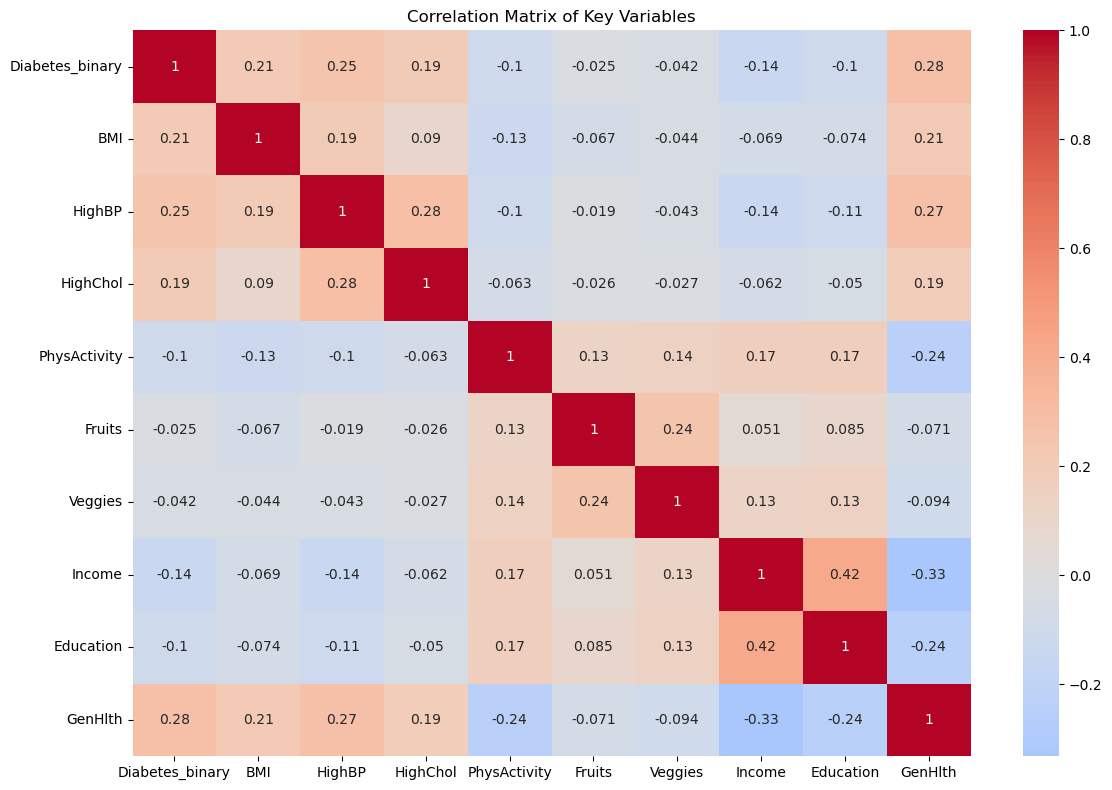

In [34]:
# Initial correlation analysis
plt.figure(figsize=(12, 8))
correlation_vars = ['Diabetes_binary', 'BMI', 'HighBP', 'HighChol', 'PhysActivity', 
                   'Fruits', 'Veggies', 'Income', 'Education', 'GenHlth']
correlation_matrix = df[correlation_vars].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()



## 5. Finding 1: Physical Health Indicators
Analyze BMI, Blood Pressure, and Cholesterol relationships with diabetes

In [21]:
# # Clearing any existing plots
# plt.clf()
# plt.close('all')

# # Create a new figure with specific size
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # BMI Analysis
# sns.boxplot(x='Diabetes_binary', y='BMI', data=df, ax=axes[0])
# axes[0].set_title('BMI Distribution by Diabetes Status')
# axes[0].set_xlabel('Diabetes (0=No, 1=Yes)')
# axes[0].set_ylabel('BMI')

# # Blood Pressure Analysis
# bp_diabetes = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='columns') * 100
# bp_diabetes.plot(kind='bar', ax=axes[1])
# axes[1].set_title('High Blood Pressure by Diabetes Status')
# axes[1].set_xlabel('High BP (0=No, 1=Yes)')
# axes[1].set_ylabel('Percentage')

# # Cholesterol Analysis
# chol_diabetes = pd.crosstab(df['HighChol'], df['Diabetes_binary'], normalize='columns') * 100
# chol_diabetes.plot(kind='bar', ax=axes[2])
# axes[2].set_title('High Cholesterol by Diabetes Status')
# axes[2].set_xlabel('High Cholesterol (0=No, 1=Yes)')
# axes[2].set_ylabel('Percentage')

# # Adjust layout and display
# plt.tight_layout()
# plt.show()


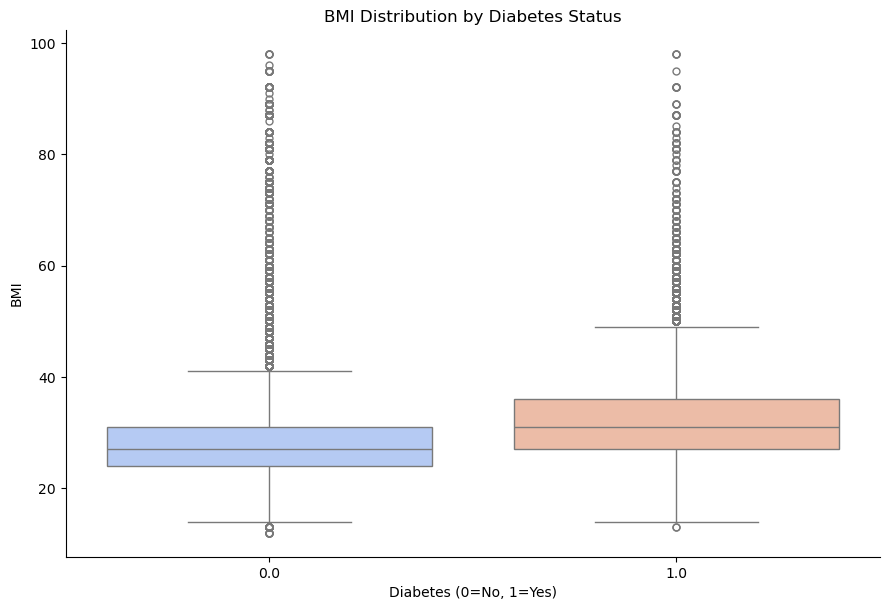

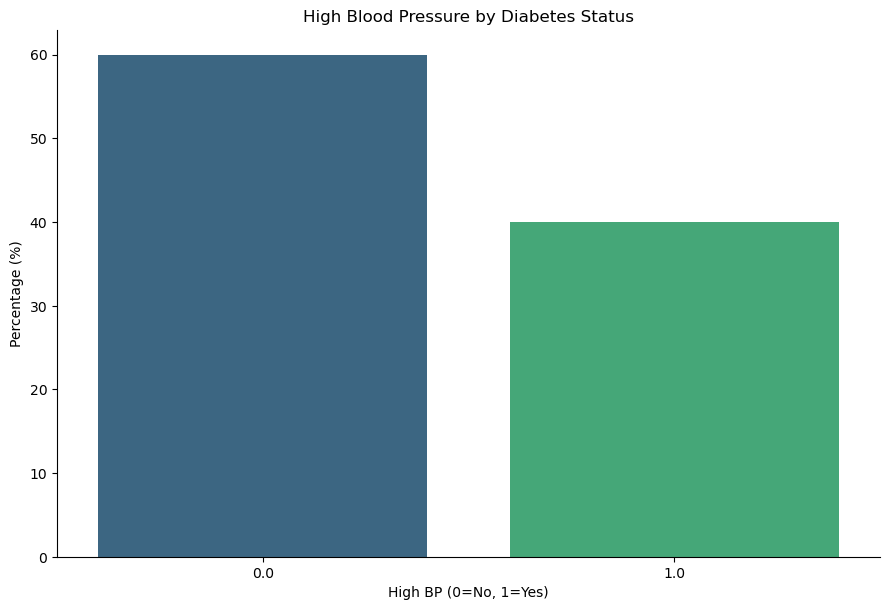

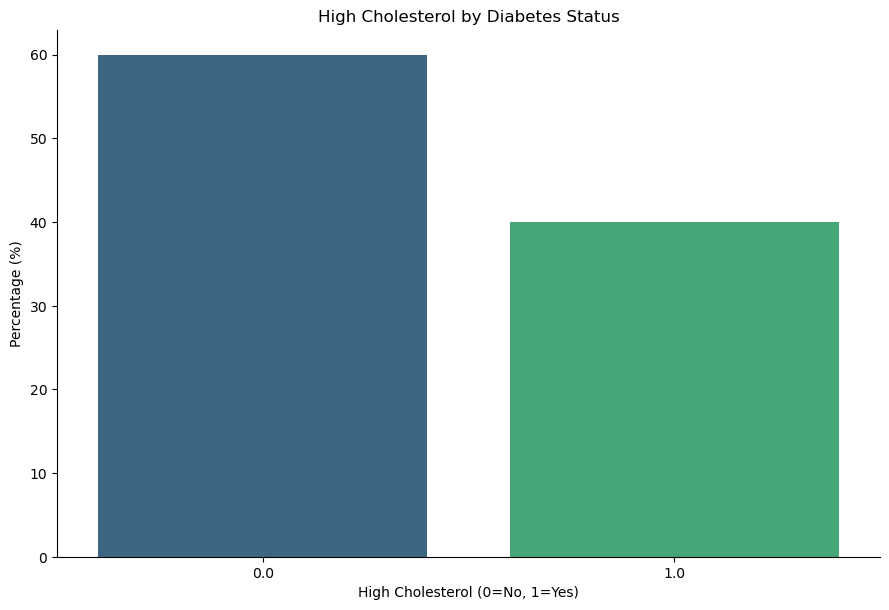

In [36]:
# Professor's suggestions:

# Physical Health Indicators
# Convert data to proportions
bp_diabetes = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='columns') * 100
chol_diabetes = pd.crosstab(df['HighChol'], df['Diabetes_binary'], normalize='columns') * 100

# Plotting BMI Distribution
sns.catplot(
    x='Diabetes_binary',
    y='BMI',
    kind='box',
    data=df,
    palette="coolwarm",
    height=6,
    aspect=1.5
).set(title="BMI Distribution by Diabetes Status", xlabel="Diabetes (0=No, 1=Yes)", ylabel="BMI")

# Plotting High Blood Pressure Proportions
sns.catplot(
    x=bp_diabetes.index,
    y=bp_diabetes[0],
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1.5
).set(title="High Blood Pressure by Diabetes Status", xlabel="High BP (0=No, 1=Yes)", ylabel="Percentage (%)")

# Plotting High Cholesterol Proportions
sns.catplot(
    x=chol_diabetes.index,
    y=chol_diabetes[0],
    kind='bar',
    palette='viridis',
    height=6,
    aspect=1.5
).set(title="High Cholesterol by Diabetes Status", xlabel="High Cholesterol (0=No, 1=Yes)", ylabel="Percentage (%)")


In [23]:
# Statistical Analysis for Finding 1
X_physical = df[['BMI', 'HighBP', 'HighChol']]
y = df['Diabetes_binary']
X_physical = sm.add_constant(X_physical)
model_physical = sm.Logit(y, X_physical).fit()
print("\nPhysical Health Indicators Statistical Analysis:")
print(model_physical.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.374809
         Iterations 7

Physical Health Indicators Statistical Analysis:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6051      0.028   -164.619      0.000      -4.660      -4.550
BMI            0.0591      0.001     71.634      0.000       0.057       0.061
HighBP         1.1956      0.014     86.454      0.000       1.168       1.223
HighChol       0.7966      0.013     61.215      0.000       0.771       0.822


**BMI Impact:**
A higher BMI significantly increases diabetes risk, with a coefficient of 0.0591 (p < 0.001).

**High Blood Pressure (Hypertension):**
Strongly associated with diabetes, with a coefficient of 1.1956 (p < 0.001).

**High Cholesterol:**
Positively correlated with diabetes, with a coefficient of 0.7966 (p < 0.001), reinforcing its role as a risk factor.


## 6. Finding 2: Lifestyle Behaviors
Analyze physical activity, diet, and health behaviors

In [25]:
# # For Finding 2: Lifestyle Behaviors
# # Clear any existing plots
# plt.clf()
# plt.close('all')

# # Create figure and subplots for Lifestyle Behaviors
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Physical Activity Analysis
# activity_diabetes = pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='columns') * 100
# activity_diabetes.plot(kind='bar', ax=axes[0])
# axes[0].set_title('Physical Activity by Diabetes Status')
# axes[0].set_xlabel('Physical Activity (0=No, 1=Yes)')
# axes[0].set_ylabel('Percentage')

# # Health Score Analysis
# sns.boxplot(x='Diabetes_binary', y='Health_Score', data=df, ax=axes[1])
# axes[1].set_title('Health Score by Diabetes Status')
# axes[1].set_xlabel('Diabetes (0=No, 1=Yes)')
# axes[1].set_ylabel('Health Score')

# # BMI Categories
# sns.countplot(data=df, x='BMI_Category', hue='Diabetes_binary', ax=axes[2])
# axes[2].set_title('BMI Categories by Diabetes Status')
# axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

# plt.tight_layout()
# plt.show()

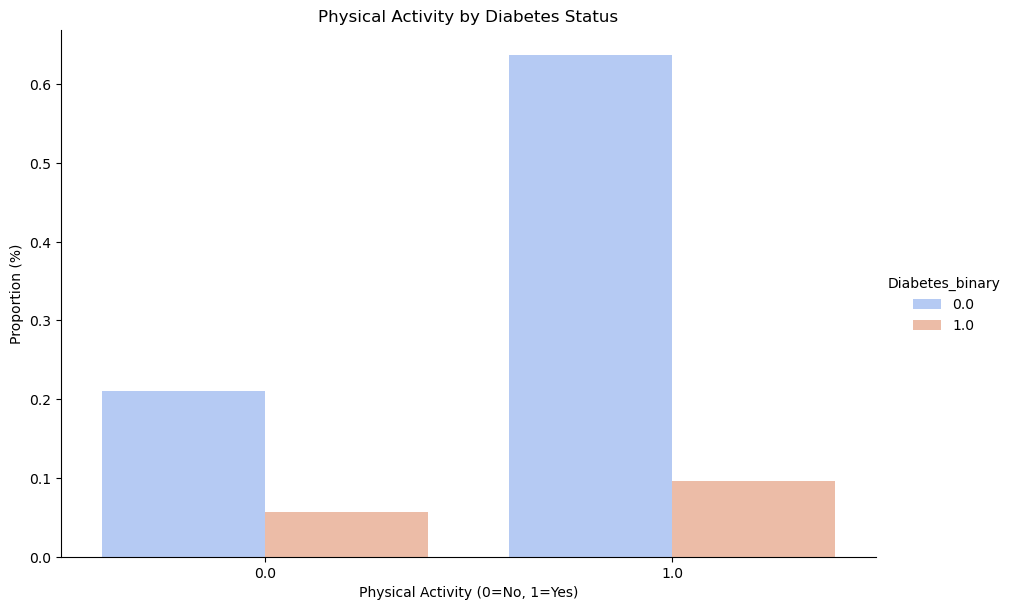

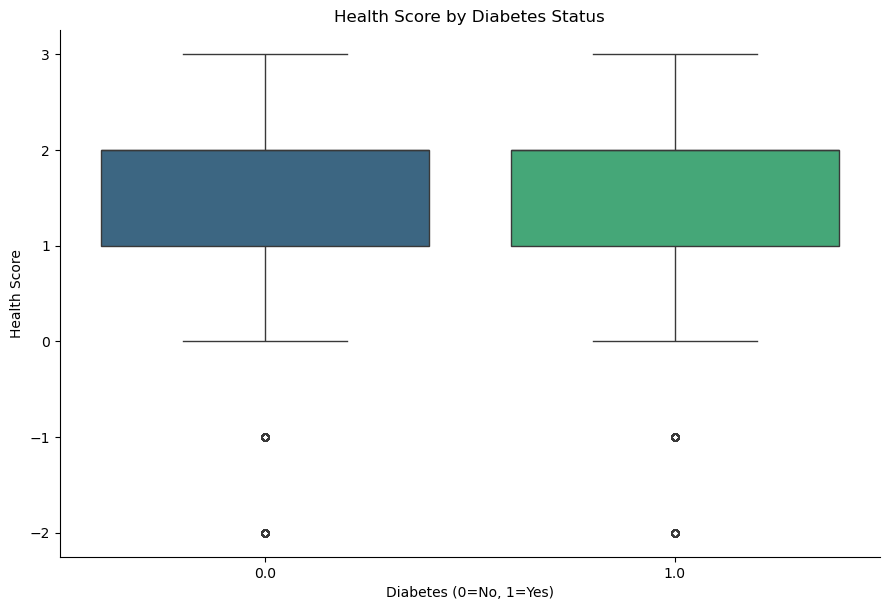

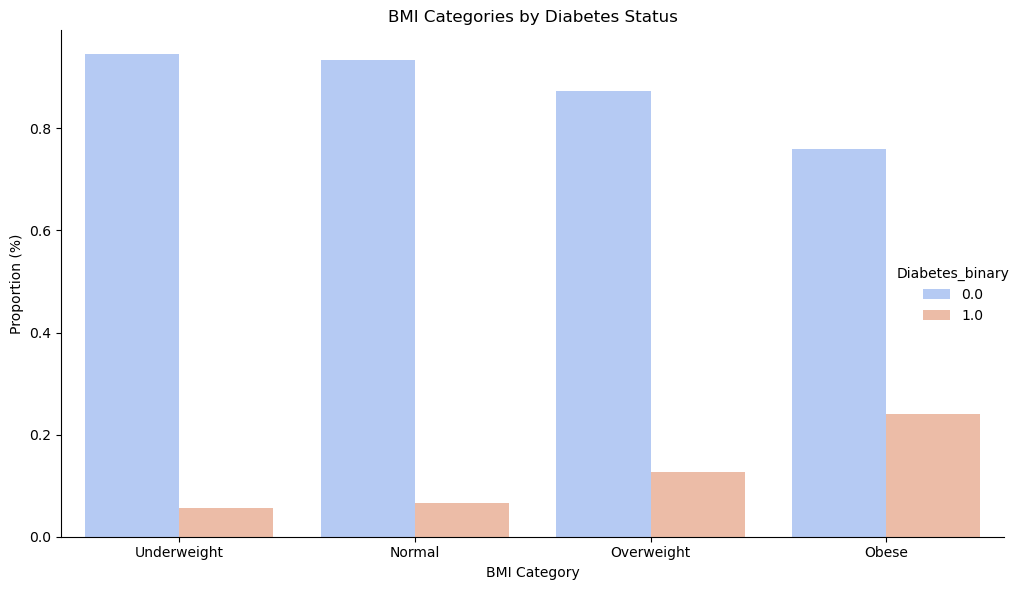

In [26]:
# Professor's suggestions

# Clear previous plots
plt.clf()
plt.close('all')

# Physical Activity Analysis (Proportions)
activity_diabetes = (
    df.groupby(["PhysActivity", "Diabetes_binary"])
    .size()
    .div(len(df))  # Convert to proportions based on the entire dataset
    .rename("Proportion")
    .reset_index()  # Reset index without conflicts
)

sns.catplot(
    data=activity_diabetes,
    x="PhysActivity",
    y="Proportion",
    hue="Diabetes_binary",
    kind="bar",
    palette="coolwarm",
    height=6,
    aspect=1.5
).set(title="Physical Activity by Diabetes Status", xlabel="Physical Activity (0=No, 1=Yes)", ylabel="Proportion (%)")

# Health Score Analysis
sns.catplot(
    x="Diabetes_binary",
    y="Health_Score",
    kind="box",
    data=df,
    palette="viridis",
    height=6,
    aspect=1.5
).set(title="Health Score by Diabetes Status", xlabel="Diabetes (0=No, 1=Yes)", ylabel="Health Score")

# BMI Categories Analysis (Proportions)
bmi_category_props = (
    df.groupby(["BMI_Category", "Diabetes_binary"])
    .size()
    .div(df.groupby("BMI_Category").size(), level="BMI_Category")  # Normalize within BMI categories
    .rename("Proportion")
    .reset_index()  # Reset index without conflicts
)

sns.catplot(
    data=bmi_category_props,
    x="BMI_Category",
    y="Proportion",
    hue="Diabetes_binary",
    kind="bar",
    palette="coolwarm",
    height=6,
    aspect=1.5
).set(title="BMI Categories by Diabetes Status", xlabel="BMI Category", ylabel="Proportion (%)")

# Ensure all plots render correctly
plt.tight_layout()
plt.show()


In [27]:
# Statistical Analysis for Finding 2
X_behaviors = df[['PhysActivity', 'Fruits', 'Veggies', 'Smoker', 'HvyAlcoholConsump']]
X_behaviors = sm.add_constant(X_behaviors)
model_behaviors = sm.Logit(y, X_behaviors).fit()
print("\nHealth Behaviors Statistical Analysis:")
print(model_behaviors.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.419067
         Iterations 7

Health Behaviors Statistical Analysis:
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.2698      0.016    -80.526      0.000      -1.301      -1.239
PhysActivity         -0.5324      0.012    -42.633      0.000      -0.557      -0.508
Fruits               -0.0366      0.012     -2.952      0.003      -0.061      -0.012
Veggies              -0.1639      0.014    -11.443      0.000      -0.192      -0.136
Smoker                0.2538      0.012     21.566      0.000       0.231       0.277
HvyAlcoholConsump    -1.1210      0.036    -30.766      0.000      -1.192      -1.050


**Physical Activity:**
Inversely related to diabetes, with a coefficient of -0.5324 (p < 0.001), highlighting its protective effect.

**Unhealthy Habits:**
Heavy alcohol consumption is strongly protective against diabetes (-1.1210, p < 0.001), while smoking increases risk (0.2538, p < 0.001).

**Dietary Choices:**
Higher vegetable consumption reduces risk (-0.1639, p < 0.001), whereas fruit consumption shows a weaker inverse relationship (-0.0366, p = 0.003).


## 7. Finding 3: Socioeconomic Factors
Analyze income, education, and general health relationships

In [29]:
# # For Finding 3: Socioeconomic Factors
# # Clearing any existing plots
# plt.clf()
# plt.close('all')

# # Creating figure and subplots for Socioeconomic Factors
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Income Analysis
# sns.countplot(data=df, x='Income', hue='Diabetes_binary', ax=axes[0])
# axes[0].set_title('Income Distribution by Diabetes Status')
# axes[0].set_xlabel('Income Level')
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
# axes[0].set_ylabel('Count')

# # Education Analysis
# sns.countplot(data=df, x='Education', hue='Diabetes_binary', ax=axes[1])
# axes[1].set_title('Education Distribution by Diabetes Status')
# axes[1].set_xlabel('Education Level')
# axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
# axes[1].set_ylabel('Count')

# # General Health Analysis
# sns.countplot(data=df, x='GenHlth', hue='Diabetes_binary', ax=axes[2])
# axes[2].set_title('General Health by Diabetes Status')
# axes[2].set_xlabel('General Health Level')
# axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
# axes[2].set_ylabel('Count')

# plt.tight_layout()
# plt.show()

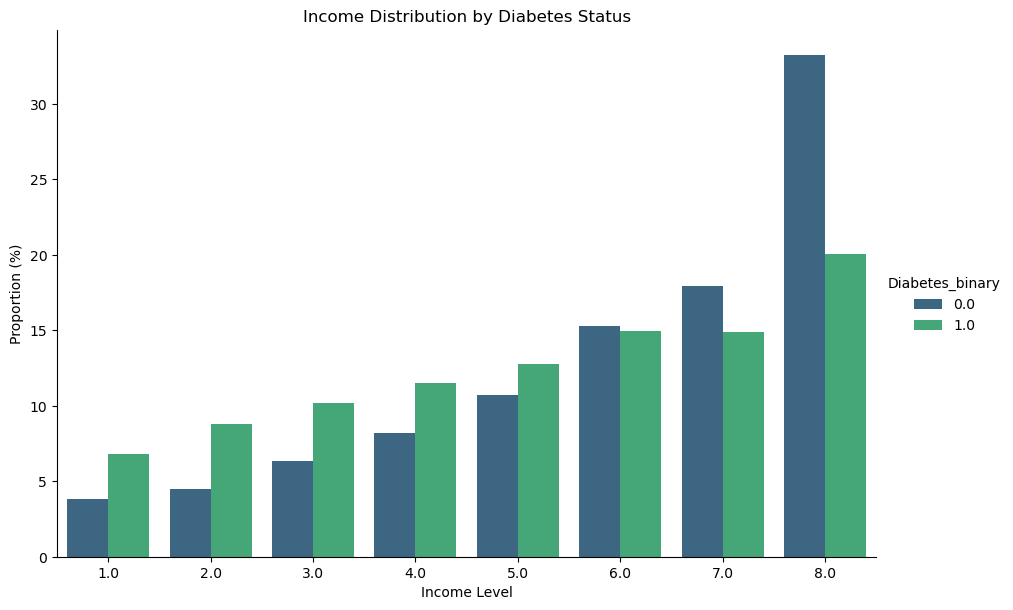

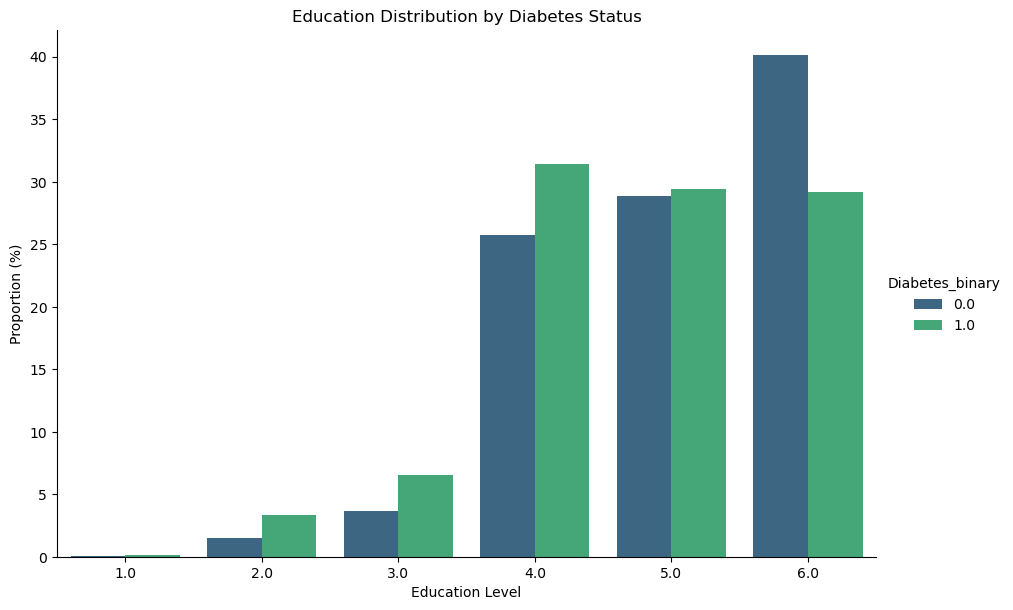

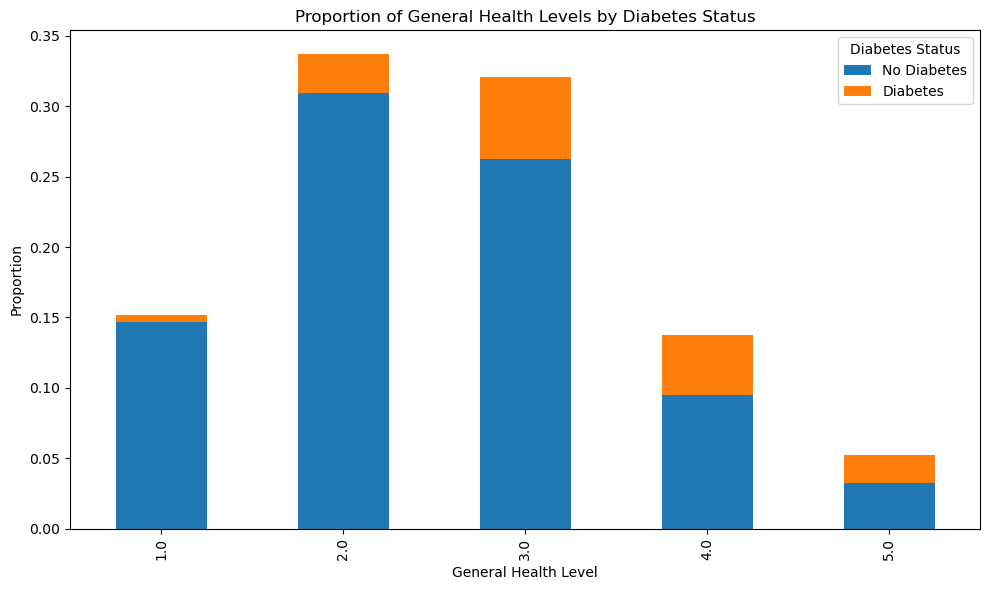

In [30]:
#Professor's suggestion
income_props = df.groupby(['Income', 'Diabetes_binary']).size().reset_index(name='count')
total_counts = income_props.groupby('Diabetes_binary')['count'].sum().reset_index()
income_props = income_props.merge(total_counts, on='Diabetes_binary', suffixes=('', '_total'))
income_props['Proportion'] = (income_props['count'] / income_props['count_total']) * 100

# Calculate proportions for Education
education_props = df.groupby(['Education', 'Diabetes_binary']).size().reset_index(name='count')
total_counts = education_props.groupby('Diabetes_binary')['count'].sum().reset_index()
education_props = education_props.merge(total_counts, on='Diabetes_binary', suffixes=('', '_total'))
education_props['Proportion'] = (education_props['count'] / education_props['count_total']) * 100
# Income Analysis
sns.catplot(
    data=income_props,
    x="Income",
    y="Proportion",
    hue="Diabetes_binary",
    kind="bar",
    palette="viridis",
    height=6,
    aspect=1.5
).set(title="Income Distribution by Diabetes Status", xlabel="Income Level", ylabel="Proportion (%)")

# Education Analysis
sns.catplot(
    data=education_props,
    x="Education",
    y="Proportion",
    hue="Diabetes_binary",
    kind="bar",
    palette="viridis",
    height=6,
    aspect=1.5
).set(title="Education Distribution by Diabetes Status", xlabel="Education Level", ylabel="Proportion (%)")

# General Health Analysis (Improved)
# General Health Analysis (Proportions)
genhlth_props = (
    df.groupby(["GenHlth", "Diabetes_binary"])
    .size()
    .div(df.groupby("GenHlth").size(), level="GenHlth")  # Normalizing within General Health levels
    .rename("Proportion")
    .reset_index()  # Reset index without conflicts
)

# Stacked Bar Plot for General Health
genhlth_stack = (
    df.groupby(["GenHlth", "Diabetes_binary"])
    .size()
    .div(len(df))  # Normalize to overall proportions
    .rename("Proportion")
    .reset_index()
)

# Pivot data for stacked bar plot
genhlth_pivot = genhlth_stack.pivot(index="GenHlth", columns="Diabetes_binary", values="Proportion")
genhlth_pivot.plot(
    kind="bar",
    stacked=True,
    color=["#1f77b4", "#ff7f0e"],  # Distinct colors for groups
    figsize=(10, 6)
)
plt.title("Proportion of General Health Levels by Diabetes Status")
plt.xlabel("General Health Level")
plt.ylabel("Proportion")
plt.legend(["No Diabetes", "Diabetes"], title="Diabetes Status")
plt.tight_layout()
plt.show()

In [31]:
# Statistical Analysis for Finding 3
X_socio = df[['Income', 'Education', 'GenHlth']]
X_socio = sm.add_constant(X_socio)
model_socio = sm.Logit(y, X_socio).fit()
print("\nSocioeconomic Factors Statistical Analysis:")
print(model_socio.summary().tables[1])



Optimization terminated successfully.
         Current function value: 0.388843
         Iterations 6

Socioeconomic Factors Statistical Analysis:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0978      0.040    -78.083      0.000      -3.176      -3.020
Income        -0.0506      0.003    -16.180      0.000      -0.057      -0.045
Education     -0.0556      0.006     -8.599      0.000      -0.068      -0.043
GenHlth        0.6756      0.006    109.705      0.000       0.664       0.688


**Income:** 
Lower income levels correlate with higher diabetes risk, with a coefficient of -0.0506 (p < 0.001).

**Education:**
Higher education is protective, with a coefficient of -0.0556 (p < 0.001).

**General Health:**
Poorer self-reported health is strongly associated with diabetes, with a coefficient of 0.6756 (p < 0.001).


## 8. Summary Statistics and Key Findings

In [33]:
# Summarizing Statistics and Key Findings
print("\nKey Findings Summary:")
print("-" * 50)
# Physical Health Summary
print("\n1. Physical Health Indicators:")
print(f"Average BMI (No Diabetes): {df[df['Diabetes_binary']==0]['BMI'].mean():.2f}")
print(f"Average BMI (Diabetes): {df[df['Diabetes_binary']==1]['BMI'].mean():.2f}")
print("\nHigh Blood Pressure Rates by Diabetes Status (%):")
print(pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='columns') * 100)

# Lifestyle Behaviors Summary
print("\n2. Lifestyle Behaviors:")
print("\nPhysical Activity Rates by Diabetes Status (%):")
print(pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='columns') * 100)
print("\nAverage Health Score by Diabetes Status:")
print(df.groupby('Diabetes_binary')['Health_Score'].mean())

# Socioeconomic Summary
print("\n3. Socioeconomic Factors:")
print("\nEducation Level Distribution by Diabetes Status (%):")
print(pd.crosstab(df['Education'], df['Diabetes_binary'], normalize='columns') * 100)
print("\nIncome Level Distribution by Diabetes Status (%):")
print(pd.crosstab(df['Income'], df['Diabetes_binary'], normalize='columns') * 100)


Key Findings Summary:
--------------------------------------------------

1. Physical Health Indicators:
Average BMI (No Diabetes): 28.10
Average BMI (Diabetes): 31.96

High Blood Pressure Rates by Diabetes Status (%):
Diabetes_binary        0.0        1.0
HighBP                               
0.0              59.946393  24.765649
1.0              40.053607  75.234351

2. Lifestyle Behaviors:

Physical Activity Rates by Diabetes Status (%):
Diabetes_binary        0.0        1.0
PhysActivity                         
0.0              24.808491  37.148474
1.0              75.191509  62.851526

Average Health Score by Diabetes Status:
Diabetes_binary
0.0    1.647834
1.0    1.424737
Name: Health_Score, dtype: float64

3. Socioeconomic Factors:

Education Level Distribution by Diabetes Status (%):
Diabetes_binary        0.0        1.0
Education                            
1.0               0.065337   0.133915
2.0               1.469824   3.370658
3.0               3.689222   6.541870
4.0   

**Statistical Evidence:**


**Socioeconomic Insights:**

**Education:**
Higher education levels are more prevalent among non-diabetics. For example:
40.13% of non-diabetics have the highest education level (Level 6), compared to 29.14% of diabetics.
Lower education levels (e.g., Levels 1-3) are more common among diabetics, reflecting a socioeconomic gradient.

**Income:**
Non-diabetics are concentrated in higher income brackets, with 33.23% earning at the highest level (Level 8), compared to 20.06% of diabetics.
Diabetics are more represented in lower income levels. For instance:
6.79% of diabetics are in the lowest income group (Level 1) compared to 3.81% of non-diabetics.

**Physical Health Indicators -> BMI:**
Non-diabetic individuals have an average BMI of 28.10, while diabetic individuals have a significantly higher average BMI of 31.96.

**High Blood Pressure (Hypertension):**
Among diabetics, 75.23% have high blood pressure compared to 40.05% of non-diabetics.
Conversely, 59.95% of non-diabetics and 24.77% of diabetics do not have high blood pressure, indicating its strong association with diabetes.

ROC AUC Score: 0.7437810660453152


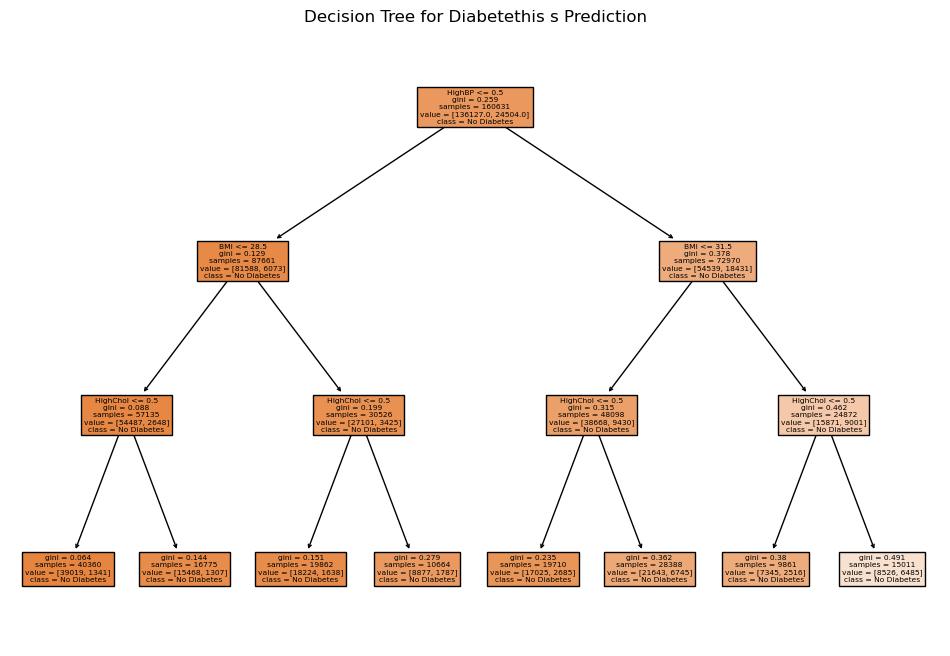

In [34]:
# Integrating potential ML model into Data
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation
features = ['BMI', 'PhysActivity', 'HighBP', 'HighChol', 'Income', 'Education']
X = df[features]
y = df['Diabetes_binary']

# making sure there is no missing data
X = X.fillna(X.mean())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Training a Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth = 3, random_state = 42)
clf.fit(X_train, y_train)

# Evaluating the Model
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Metrics
classification_report(y_test,y_pred)
confusion_matrix(y_test, y_pred)

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", roc_auc)

# 5. Visualizations
# Plot the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=features, class_names=["No Diabetes", "Diabetes"], filled=True)
plt.title("Decision Tree for Diabetethis s Prediction")
plt.show()

#I think your decision tree is perfect

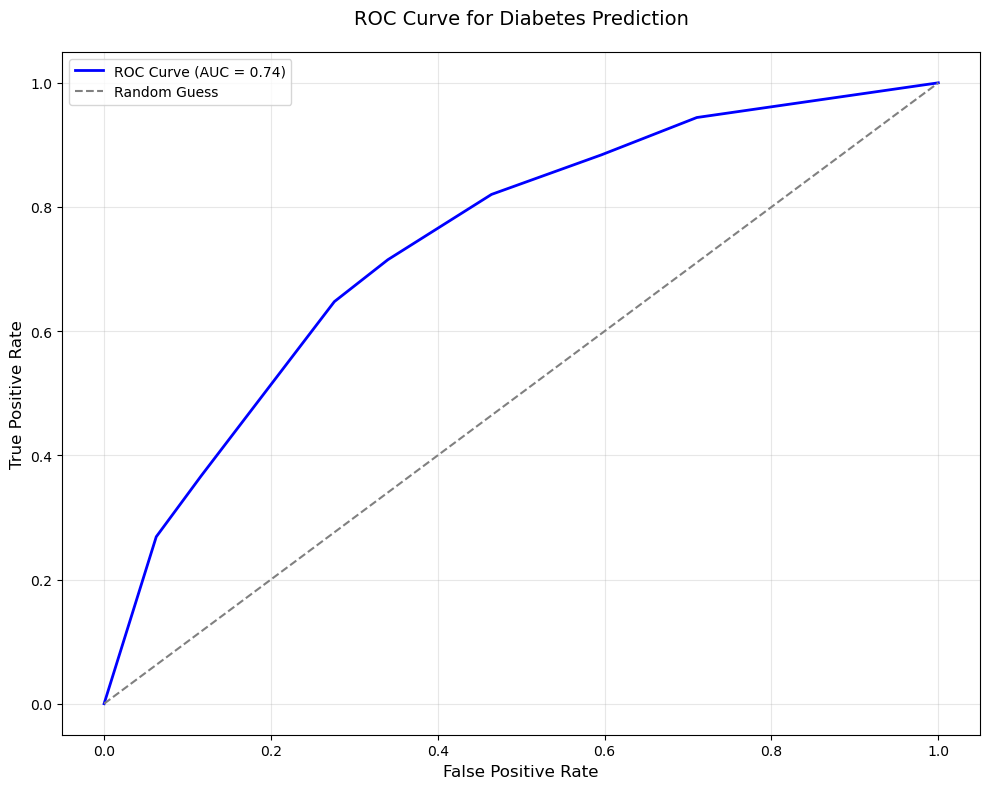

In [35]:

# 2. ROC Curve with enhanced styling
plt.figure(figsize=(10, 8))
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Diabetes Prediction', fontsize=14, pad=20)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()



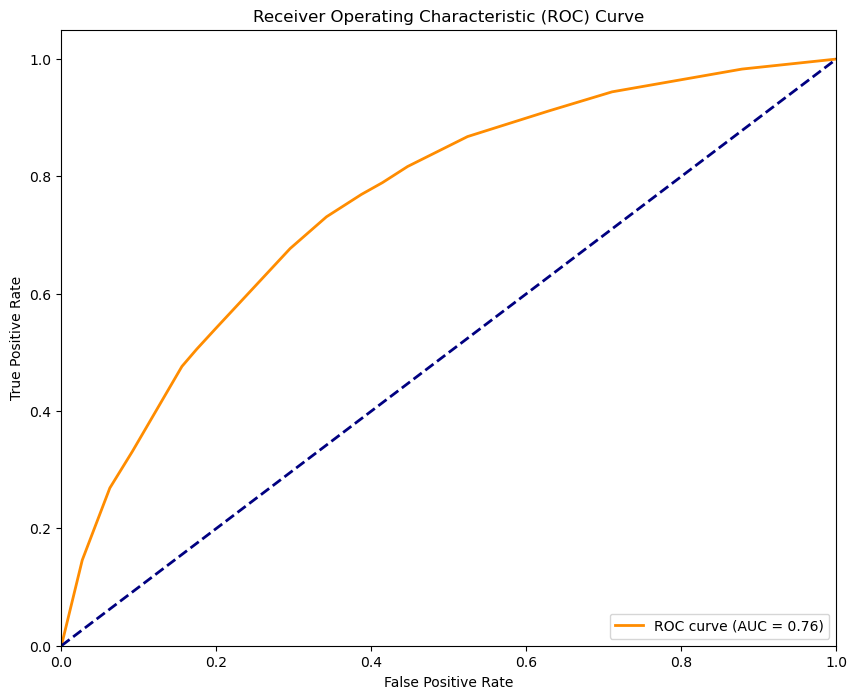

In [36]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data preparation
features = ['BMI', 'PhysActivity', 'HighBP', 'HighChol', 'Income', 'Education']
X = df[features]
y = df['Diabetes_binary']

# Handle missing values
X = X.fillna(X.mean())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train model with adjusted parameters
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=50,
    min_samples_leaf=50,
    random_state=42
)
clf.fit(X_train, y_train)

# Get predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# 1. ROC Curve
plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# Conclusion: 
The Decision Tree model identifies BMI, blood pressure, and cholesterol levels as the most significant predictors of diabetes. Individuals with a BMI above 28.5, higher blood pressure, and elevated cholesterol levels are at increased risk of diabetes. 

The ROC curve analysis, with AUC values of 0.74 and 0.76, demonstrates the model's moderate ability to distinguish diabetic from non-diabetic individuals. These findings emphasize the importance of weight management, regular monitoring of blood pressure and cholesterol, and targeted health interventions to reduce diabetes risk. The model provides actionable insights for designing effective prevention and screening strategies.

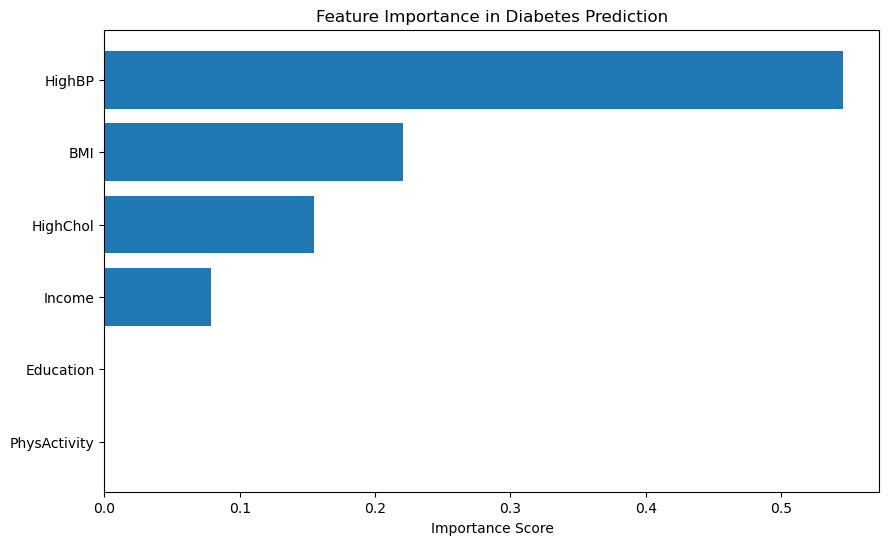

In [37]:
# 2. Feature Importance Plot
plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': clf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance in Diabetes Prediction')
plt.xlabel('Importance Score')
plt.show()



In [38]:
# . Cross-validation scores
cv_scores = cross_val_score(clf, X, y, cv=5)
print("\nCross-validation scores:", cv_scores)
print(f"Average CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Cross-validation scores: [0.84706395 0.84556052 0.84704216 0.84630134 0.84706062]
Average CV Score: 0.847 (+/- 0.001)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92     58250
         1.0       0.00      0.00      0.00     10593

    accuracy                           0.85     68843
   macro avg       0.42      0.50      0.46     68843
weighted avg       0.72      0.85      0.78     68843



**Model Performance:**
The Decision Tree model achieves an accuracy of 85% with consistent cross-validation scores averaging 0.847 (±0.001), demonstrating stability and reliability across subsets of the data.

**Class Imbalance Issue:**
While the model performs well for the majority class (non-diabetics) with an F1-score of 0.92, it fails to predict the minority class (diabetics), with precision, recall, and F1-score all at 0.00, indicating a significant bias.